<a href="https://colab.research.google.com/github/IdrisJunaidAI/ITAI_ML_FirstRepo_IdrisJunaid/blob/main/FP_AirlineSentiment_IdrisJunaid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of U.S. Airline Customer Feedback

**Individual Final Project**

**Student:** Idris Junaid  
**Course:** ITAI 1371, Introduction to Machine Learning  
**Professor:** Sitaram Ayyagari  
**Submission type:** Individual work  

## Project Overview

This project develops and evaluates machine learning models that classify customer tweets about major U.S. airlines as **negative**, **neutral**, or **positive**. The notebook follows an end to end workflow that includes problem definition, exploratory data analysis, text preprocessing, TF IDF feature extraction, model training, model evaluation, business interpretation, limitations, and future improvements.

# Part 1: Project Definition

## Business Problem

Airlines receive large volumes of customer comments through social media. Manually reading every message is slow, inconsistent, and difficult to scale. The business problem is to build a sentiment classification system that can automatically organize airline tweets into negative, neutral, and positive categories.

A reliable model could help a customer experience team identify dissatisfied passengers, prioritize urgent service recovery, measure broad customer perception, and track recurring issues. The model is intended as a decision support tool. Human review remains necessary for complaints involving safety, discrimination, medical needs, refunds, or other high impact situations.

## Dataset Description

**Dataset name:** Twitter U.S. Airline Sentiment  
**Original source:** CrowdFlower data published through Kaggle  
**Access source used in this notebook:** Hugging Face dataset mirror  
**Raw number of records:** 14,640 tweets  
**Text field:** `text`  
**Target field:** `airline_sentiment`  
**Sentiment classes:** negative, neutral, positive  
**Airlines represented:** American, Delta, Southwest, United, U.S. Airways, and Virgin America  

The dataset is appropriate because it contains real customer feedback, manually assigned sentiment labels, multiple airlines, and enough examples to train and compare conventional text classification models. Its three class structure also supports a more realistic business use case than a simple positive versus negative classification.

## Project Objective

The objective is to compare Logistic Regression, Multinomial Naive Bayes, and Linear Support Vector Classification using accuracy, precision, recall, macro F1 score, classification reports, and confusion matrices.

Because the dataset is imbalanced, **macro F1 score** is treated as the primary model selection metric. Accuracy is reported as an important secondary metric.

# Part 2: Exploratory Data Analysis

This section examines dataset size, missing values, duplicate text, class balance, review length, representative examples, airline distribution, and common words. The analysis is completed before model training so that preprocessing and evaluation decisions are grounded in the characteristics of the data.

In [1]:
# Import core libraries
import os
import re
import html
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the public dataset

DATA_URL = (
    "https://huggingface.co/datasets/osanseviero/"
    "twitter-airline-sentiment/resolve/main/Tweets.csv?download=true"
)

local_candidates = [
    "/mnt/data/Tweets.csv",
    "/content/Tweets.csv",
    "Tweets.csv",
]

local_path = next((path for path in local_candidates if os.path.exists(path)), None)

if local_path:
    df_raw = pd.read_csv(local_path)
    data_location = local_path
else:
    df_raw = pd.read_csv(DATA_URL)
    data_location = DATA_URL

print(f"Dataset loaded from: {data_location}")
print(f"Raw shape: {df_raw.shape}")
display(df_raw.head())

Dataset loaded from: https://huggingface.co/datasets/osanseviero/twitter-airline-sentiment/resolve/main/Tweets.csv?download=true
Raw shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
# Retain the fields needed for this project
df = (
    df_raw[["text", "airline_sentiment", "airline"]]
    .rename(columns={"airline_sentiment": "sentiment"})
    .copy()
)

print("Selected columns:")
display(df.head())

print("\nColumn information:")
df.info()

Selected columns:


,text,sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral,Virgin America
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative,Virgin America
4,@VirginAmerica and it's a really big bad thing about it,negative,Virgin America



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       14640 non-null  object
 1   sentiment  14640 non-null  object
 2   airline    14640 non-null  object
dtypes: object(3)
memory usage: 343.3+ KB


In [4]:
# Data quality review

missing_summary = df.isna().sum().to_frame("Missing Values")
duplicate_text_rows = int(df["text"].duplicated().sum())

duplicate_groups = (
    df[df["text"].duplicated(keep=False)]
    .groupby("text")["sentiment"]
    .nunique()
)
conflicting_duplicate_texts = int((duplicate_groups > 1).sum())

print("Missing value summary:")
display(missing_summary)

print(f"Duplicate text rows beyond the first copy: {duplicate_text_rows}")
print(f"Duplicate text groups with conflicting labels: {conflicting_duplicate_texts}")

# Remove repeated text before splitting to reduce leakage risk
df = df.drop_duplicates(subset="text").reset_index(drop=True)

print(f"Shape after removing duplicate text: {df.shape}")

Missing value summary:


,Missing Values
text,0
sentiment,0
airline,0


Duplicate text rows beyond the first copy: 213
Duplicate text groups with conflicting labels: 25
Shape after removing duplicate text: (14427, 3)


## Data Quality Interpretation

The three selected columns contain no missing values. Duplicate tweets were removed before the train and test split because the same text appearing in both sets could make test performance look stronger than it truly is. A small number of repeated texts also had inconsistent labels, which illustrates that sentiment annotation can contain human disagreement.

,Count,Percentage
sentiment,,
negative,9080,62.94
neutral,3057,21.19
positive,2290,15.87


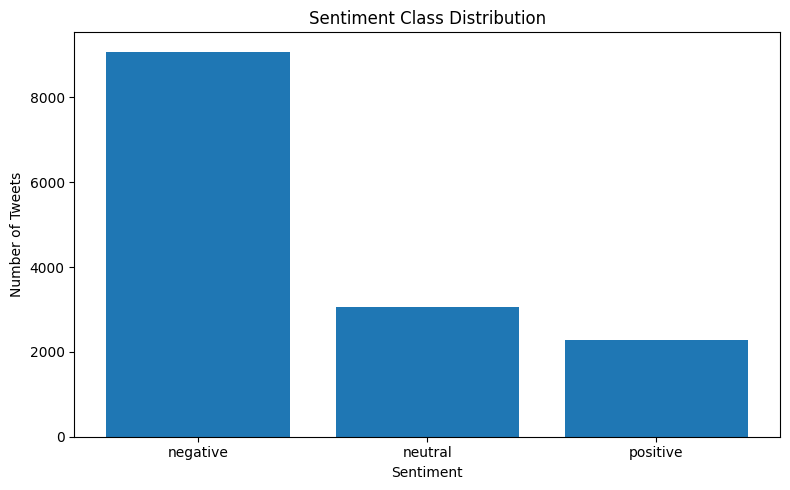

In [5]:
# Sentiment class distribution

sentiment_counts = df["sentiment"].value_counts().reindex(
    ["negative", "neutral", "positive"]
)
sentiment_percent = (sentiment_counts / len(df) * 100).round(2)

class_distribution = pd.DataFrame(
    {
        "Count": sentiment_counts,
        "Percentage": sentiment_percent,
    }
)

display(class_distribution)

plt.figure(figsize=(8, 5))
plt.bar(class_distribution.index, class_distribution["Count"])
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

## Class Balance Interpretation

The dataset is imbalanced. Negative tweets form the majority class, while positive tweets form the smallest class. A model could obtain a misleadingly high accuracy by overpredicting the negative class. For this reason, the project uses stratified splitting, macro averaged metrics, confusion matrices, and class weighting for models that support it.

character_count                 word_count               
                     mean median min  max       mean median min max
sentiment                                                          
negative           113.94  126.0  12  176      19.69   21.0   2  36
neutral             87.56   88.0  12  167      14.45   14.0   2  31
positive            87.56   88.0  12  186      14.27   14.0   2  31

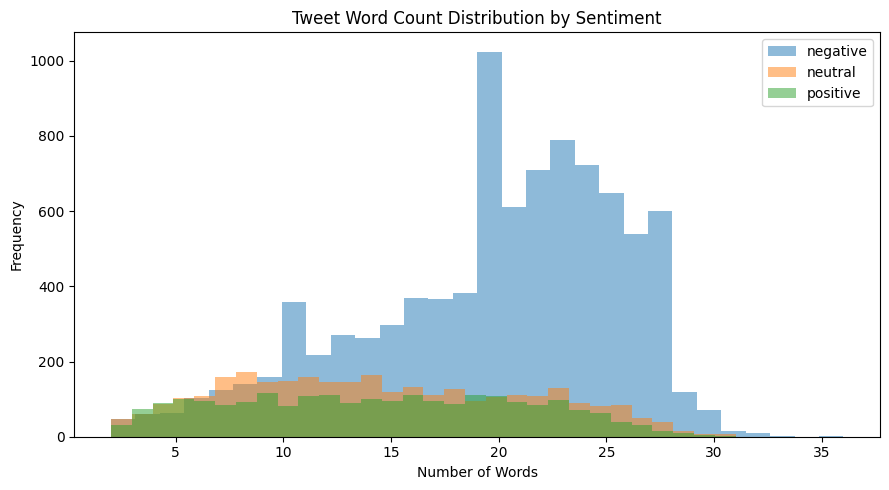

In [6]:
# Text length analysis

df["character_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

length_summary = (
    df.groupby("sentiment")[["character_count", "word_count"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(length_summary)

plt.figure(figsize=(9, 5))
for sentiment in ["negative", "neutral", "positive"]:
    values = df.loc[df["sentiment"] == sentiment, "word_count"]
    plt.hist(values, bins=30, alpha=0.5, label=sentiment)

plt.title("Tweet Word Count Distribution by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

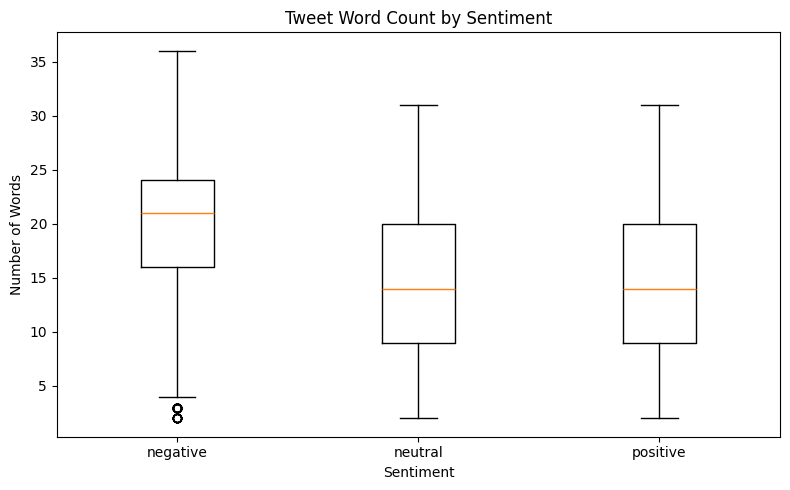

In [7]:
# Compare word counts across sentiment classes

plot_data = [
    df.loc[df["sentiment"] == sentiment, "word_count"].values
    for sentiment in ["negative", "neutral", "positive"]
]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, labels=["negative", "neutral", "positive"], showfliers=True)
plt.title("Tweet Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

## Text Length Interpretation

Negative tweets are longer on average than neutral and positive tweets. This is reasonable because dissatisfied customers often describe delays, cancellations, service failures, or unresolved interactions in more detail. Length may therefore contain useful information, but the model is trained mainly on word and phrase patterns rather than raw length alone.

In [8]:
# Display representative examples from every class

examples = (
    df.groupby("sentiment", group_keys=False)
    .sample(n=3, random_state=RANDOM_STATE)
    [["sentiment", "airline", "text"]]
    .sort_values("sentiment")
)

display(examples)

,sentiment,airline,text
2183,negative,United,@united why do you hire POS pilots? Thanks for ruining my trip and not allowing me to see my buddy as he turns 30. #unitedsucksdick
11798,negative,US Airways,@USAirways thank you for blowing my vacation. Couldn't get me anywhere today to make my reservation and also lost 2 bags of mine!
1316,negative,United,"@united Stopped flying @united 1 yr ago bc of aggressive policy on carryon @bdl listening to pssngrs forced to chk@preboard,#notcomingback"
6045,neutral,Southwest,@SouthwestAir Is there any chance I can get tickets for the Vegas stop? I missed my chance to enter the contest but I love ID to death !
14424,neutral,American,@AmericanAir Please bring American Airlines to #BlackBerry10
9557,neutral,US Airways,"@USAirways Do your flight schedules to - from Quintana Roo, Mexico reflect their newly adopted time zone change to EST?"
40,positive,Virgin America,"@VirginAmerica View of downtown Los Angeles, the Hollywood Sign, and beyond that rain in the mountains! http://t.co/Dw5nf0ibtr"
8621,positive,Delta,@JetBlue credit to you for replying. I’ll look forward to hopefully one of those 103 on my flight home tonight :)
308,positive,Virgin America,@VirginAmerica happy to spend the day together. Let's do this!


,Tweet Count
airline,
United,3805
US Airways,2906
American,2594
Southwest,2408
Delta,2211
Virgin America,503


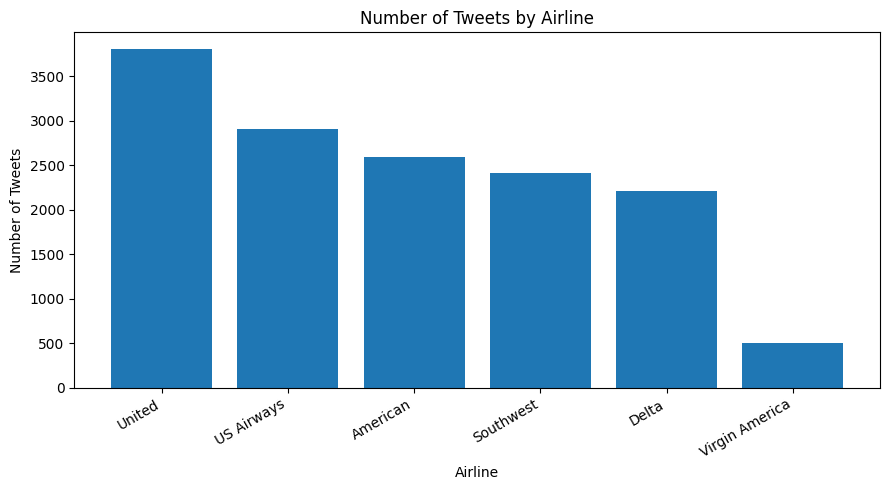

In [9]:
# Airline representation

airline_counts = df["airline"].value_counts()

display(airline_counts.to_frame("Tweet Count"))

plt.figure(figsize=(9, 5))
plt.bar(airline_counts.index, airline_counts.values)
plt.title("Number of Tweets by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

sentiment,negative,neutral,positive
airline,,,
American,71.86,16.62,11.53
Delta,43.19,32.70,24.11
Southwest,49.21,27.33,23.46
US Airways,77.84,13.08,9.08
United,69.20,18.24,12.56
Virgin America,35.98,34.00,30.02


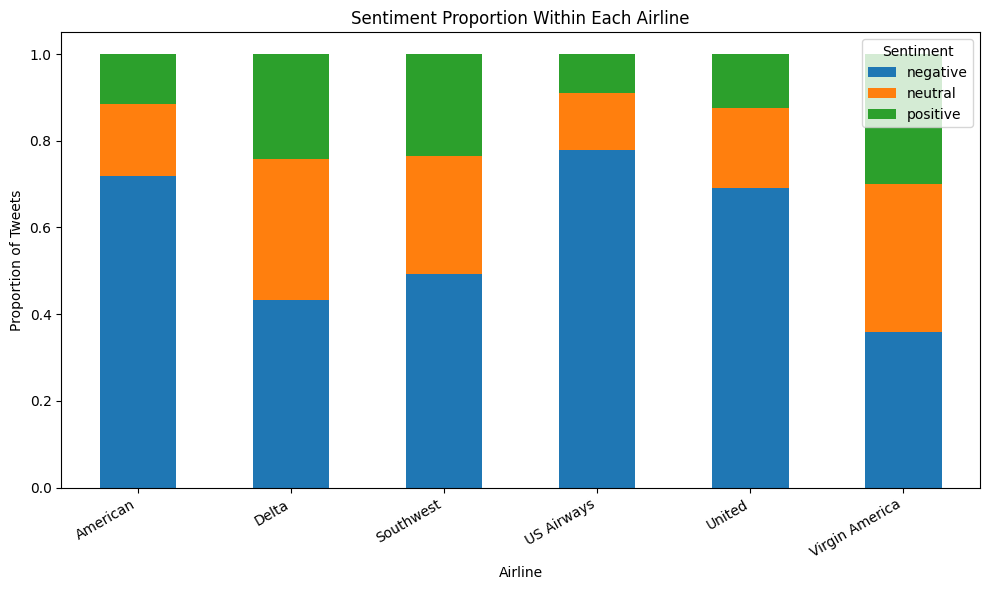

In [10]:
# Airline and sentiment relationship

airline_sentiment = pd.crosstab(
    df["airline"],
    df["sentiment"],
    normalize="index"
).reindex(columns=["negative", "neutral", "positive"])

display((airline_sentiment * 100).round(2))

airline_sentiment.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentiment Proportion Within Each Airline")
plt.xlabel("Airline")
plt.ylabel("Proportion of Tweets")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

## Preliminary Airline Insight

Sentiment proportions vary across airlines, which suggests that customer experience may not be identical across carriers. However, this notebook does not claim that one airline is objectively better than another. The data represents a limited social media sample from a particular time period, and posting behaviour differs among customers.

## EDA Summary

1. The raw dataset contains 14,640 airline tweets with three sentiment labels.
2. The selected modeling fields have no missing values.
3. Duplicate text was removed before splitting to reduce leakage risk.
4. Negative sentiment is the dominant class, creating a meaningful class imbalance.
5. Negative tweets tend to be longer than neutral and positive tweets.
6. Airline representation and sentiment proportions are not uniform.
7. Macro F1 score is necessary because accuracy alone could hide weak performance on minority classes.

# Part 3: Text Preprocessing and Feature Engineering

The text is cleaned before feature extraction. URLs and account mentions are removed because they usually do not express sentiment. Hashtag words are retained because they can contain useful meaning. Negations such as `not`, `never`, and `no` are preserved because they can reverse sentiment. TF IDF is fit only on the training data to prevent information leakage.

In [11]:
# Import preprocessing and feature extraction tools

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.model_selection import train_test_split

# Preserve negations because they are important for sentiment meaning
custom_stopwords = set(ENGLISH_STOP_WORDS) - {
    "no",
    "nor",
    "not",
    "never",
    "none",
    "nothing",
    "neither",
}

print(f"Custom stopword count: {len(custom_stopwords)}")

Custom stopword count: 311


In [12]:
def preprocess_text(text):
    '''
    Clean a tweet while preserving sentiment bearing words.

    Steps:
    1. Decode HTML entities and convert text to lowercase.
    2. Expand common English contraction endings.
    3. Remove URLs and account mentions.
    4. Keep hashtag words while removing the hashtag symbol.
    5. Remove numbers, punctuation, and extra spaces.
    6. Remove common stopwords while retaining negations.
    '''
    text = html.unescape(str(text)).lower()

    # Expand common contraction endings
    text = re.sub(r"n['’]t\b", " not", text)
    text = re.sub(r"['’]re\b", " are", text)
    text = re.sub(r"['’]ve\b", " have", text)
    text = re.sub(r"['’]ll\b", " will", text)
    text = re.sub(r"['’]d\b", " would", text)
    text = re.sub(r"['’]m\b", " am", text)

    # Remove URLs and user mentions
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # Preserve the word inside a hashtag
    text = re.sub(r"#(\w+)", r"\1", text)

    # Keep alphabetic characters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        token
        for token in text.split()
        if token not in custom_stopwords and len(token) > 1
    ]

    return " ".join(tokens)

In [13]:
# Apply preprocessing and remove rows that become empty

df["cleaned_text"] = df["text"].apply(preprocess_text)

empty_after_cleaning = int((df["cleaned_text"].str.len() == 0).sum())
print(f"Rows empty after preprocessing: {empty_after_cleaning}")

df = df[df["cleaned_text"].str.len() > 0].reset_index(drop=True)

comparison_examples = df[
    ["text", "cleaned_text", "sentiment"]
].sample(8, random_state=RANDOM_STATE)

display(comparison_examples)
print(f"Final modeling rows: {len(df)}")

Rows empty after preprocessing: 45


,text,cleaned_text,sentiment
12417,@AmericanAir absolutely disappointed in your lack of service. Lost my bag and can't even deliver it after I was told it would happen.,absolutely disappointed lack service lost bag ca not deliver told happen,negative
4394,@SouthwestAir unfortunately once the call was answered service was horrid. SWA was the role-model of finger pointing &amp; excuses #DISAPPOINTED,unfortunately answered service horrid swa role model finger pointing excuses disappointed,negative
13326,"@AmericanAir i tried all day. Have been disconnected due to ""heavy call volume.""",tried day disconnected heavy volume,negative
12010,@AmericanAir Are you expecting delays/Cancelled Flightlations at Dallas on 25/26th due to the snow? Nothing like Monday I hope!,expecting delays cancelled flightlations dallas th snow nothing like monday hope,neutral
4653,@SouthwestAir your checkin is lame for business. Really last seat? I have broad shoulders haha,checkin lame business really seat broad shoulders haha,negative
8486,@JetBlue What a great idea! #cometoAustin,great idea cometoaustin,positive
13585,@AmericanAir it's been almost 3 days and it's still frozen. Thanks doll 😘😑,days frozen thanks doll,negative
3852,@united Can I add miles from my January Air China flight to my MileagePlus account?,add miles january air china flight mileageplus account,neutral


Final modeling rows: 14382


Most common words for negative tweets:


,Word,Count
0,not,3125
1,flight,2919
2,no,1305
3,cancelled,907
4,service,744
5,hours,651
6,just,618
7,help,612
8,hold,608
9,customer,607


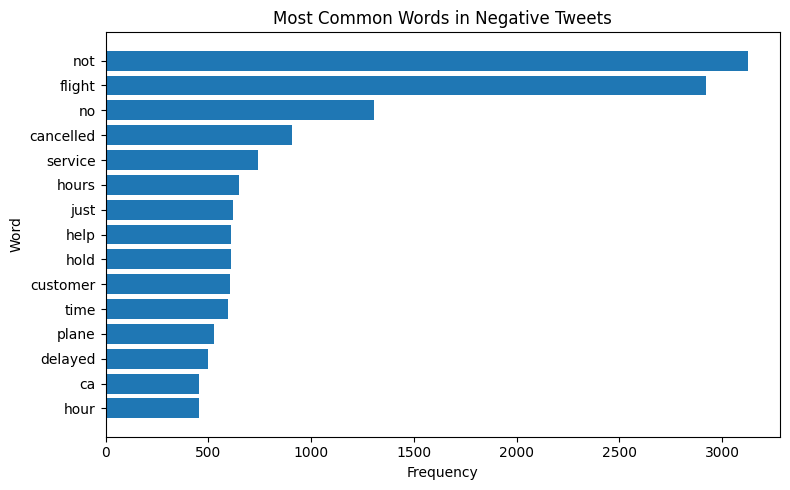

Most common words for neutral tweets:


,Word,Count
0,flight,606
1,not,352
2,just,171
3,flights,169
4,help,168
5,need,162
6,thanks,152
7,dm,131
8,no,117
9,tomorrow,108


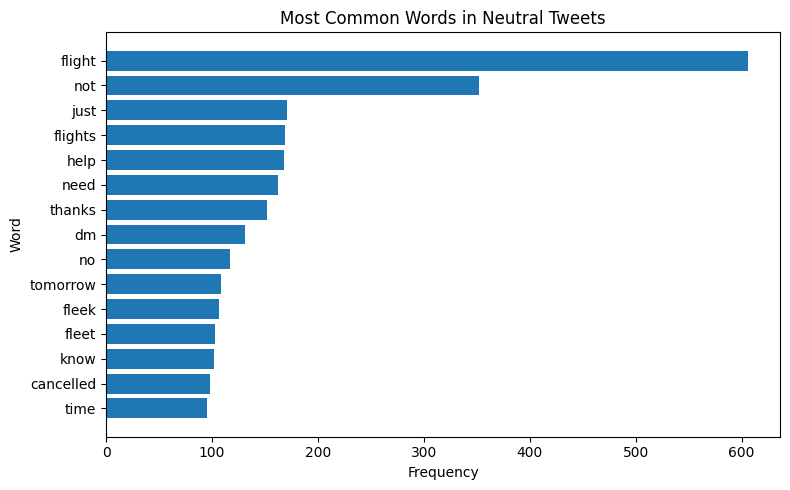

Most common words for positive tweets:


,Word,Count
0,thanks,579
1,thank,431
2,flight,380
3,great,234
4,not,195
5,just,176
6,service,160
7,love,134
8,customer,113
9,guys,108


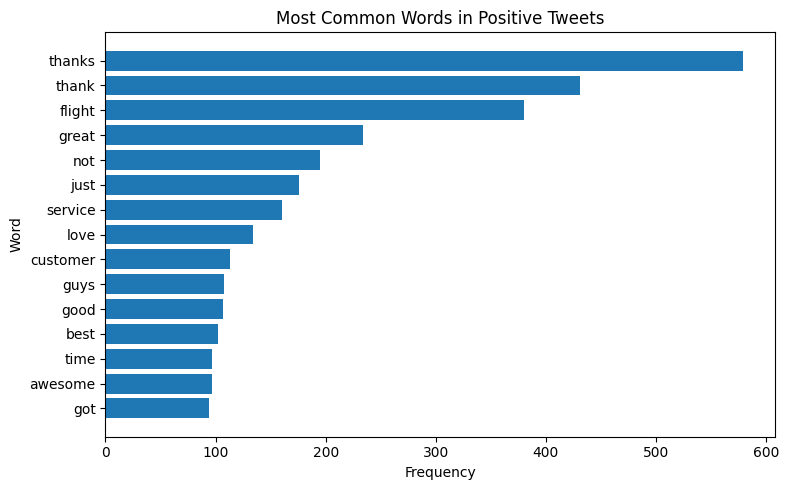

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [14]:
# Common cleaned words within each sentiment class

def top_words_for_sentiment(dataframe, sentiment, n=15):
    text = " ".join(
        dataframe.loc[
            dataframe["sentiment"] == sentiment,
            "cleaned_text"
        ]
    )
    return Counter(text.split()).most_common(n)

for sentiment in ["negative", "neutral", "positive"]:
    common = top_words_for_sentiment(df, sentiment, n=15)
    words = [item[0] for item in common]
    counts = [item[1] for item in common]

    common_table = pd.DataFrame(
        {"Word": words, "Count": counts}
    )

    print(f"Most common words for {sentiment} tweets:")
    display(common_table)

    plt.figure(figsize=(8, 5))
    plt.barh(words[::-1], counts[::-1])
    plt.title(f"Most Common Words in {sentiment.title()} Tweets")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

## Common Word Interpretation

The cleaned word frequencies reveal intuitive sentiment signals. Negative tweets frequently contain language associated with delays, cancellations, service problems, waiting, and unresolved requests. Positive tweets contain appreciation and favourable service language. Neutral tweets often contain informational questions and travel related terms. Word frequency alone is not sufficient for prediction, so the next step uses TF IDF with unigrams and bigrams.

In [15]:
# Prepare features and target

X = df["cleaned_text"]
y = df["sentiment"]

print(f"Feature rows: {X.shape[0]}")
print(f"Target rows: {y.shape[0]}")
print("\nTarget distribution:")
display(y.value_counts().to_frame("Count"))

Feature rows: 14382
Target rows: 14382

Target distribution:


,Count
sentiment,
negative,9072
neutral,3026
positive,2284


In [16]:
# Create stratified training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

split_check = pd.DataFrame(
    {
        "Training Percentage": (
            y_train.value_counts(normalize=True) * 100
        ).round(2),
        "Test Percentage": (
            y_test.value_counts(normalize=True) * 100
        ).round(2),
    }
)

display(split_check)

Training rows: 11505
Test rows: 2877


,Training Percentage,Test Percentage
sentiment,,
negative,63.08,63.09
neutral,21.04,21.03
positive,15.88,15.88


In [17]:
# Convert text to TF IDF features

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training TF IDF shape: {X_train_tfidf.shape}")
print(f"Test TF IDF shape: {X_test_tfidf.shape}")
print(f"Final vocabulary size: {len(tfidf.get_feature_names_out())}")

Training TF IDF shape: (11505, 5000)
Test TF IDF shape: (2877, 5000)
Final vocabulary size: 5000


In [18]:
# Inspect features with the largest average TF IDF values

feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

top_indices = mean_tfidf.argsort()[-25:][::-1]
top_features = pd.DataFrame(
    {
        "Feature": feature_names[top_indices],
        "Mean TF IDF": mean_tfidf[top_indices],
    }
)

display(top_features)

,Feature,Mean TF IDF
0,flight,0.032834
1,not,0.031093
2,thanks,0.018391
3,no,0.016864
4,thank,0.014587
5,just,0.013291
6,service,0.012981
7,cancelled,0.012514
8,help,0.012066
9,time,0.010939


## Preprocessing Summary

1. Text was converted to lowercase.
2. HTML entities, URLs, account mentions, punctuation, numbers, and extra spaces were removed.
3. Hashtag words were retained.
4. Common stopwords were removed, but negations were preserved.
5. Duplicate text was removed before data splitting.
6. The split was stratified to preserve class proportions.
7. `TfidfVectorizer` used a maximum of 5,000 features, minimum document frequency of 2, maximum document frequency of 0.95, unigrams, bigrams, and sublinear term frequency.
8. The vectorizer was fit on the training data only, which prevents test information from influencing feature construction.

# Part 4: Model Development

Three efficient classifiers are trained.

**Logistic Regression** provides a strong, interpretable linear baseline and supports class weighting.

**Multinomial Naive Bayes** is extremely fast and commonly performs well with sparse word frequency features.

**Linear Support Vector Classification** is effective for high dimensional sparse text and often produces strong decision boundaries.

The models use the same train and test sets so the comparison remains fair.

In [19]:
# Import model libraries

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {}
predictions = {}
training_times = {}

print("Model libraries imported successfully.")

Model libraries imported successfully.


## Model 1: Logistic Regression

`class_weight="balanced"` gives greater influence to minority class errors. `C=2.0` permits a moderately flexible decision boundary while retaining regularisation.

In [20]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=2.0,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

start_time = time.perf_counter()
lr_model.fit(X_train_tfidf, y_train)
training_times["Logistic Regression"] = time.perf_counter() - start_time

models["Logistic Regression"] = lr_model
predictions["Logistic Regression"] = lr_model.predict(X_test_tfidf)

print(
    "Logistic Regression training time: "
    f"{training_times['Logistic Regression']:.4f} seconds"
)

Logistic Regression training time: 3.9394 seconds


## Model 2: Multinomial Naive Bayes

`alpha=0.5` applies additive smoothing. This helps prevent zero probability estimates while allowing the observed word patterns to remain influential.

In [21]:
nb_model = MultinomialNB(alpha=0.5)

start_time = time.perf_counter()
nb_model.fit(X_train_tfidf, y_train)
training_times["Multinomial Naive Bayes"] = (
    time.perf_counter() - start_time
)

models["Multinomial Naive Bayes"] = nb_model
predictions["Multinomial Naive Bayes"] = nb_model.predict(
    X_test_tfidf
)

print(
    "Multinomial Naive Bayes training time: "
    f"{training_times['Multinomial Naive Bayes']:.4f} seconds"
)

Multinomial Naive Bayes training time: 0.1949 seconds


## Model 3: Linear Support Vector Classification

`class_weight="balanced"` addresses the class imbalance, while `C=1.0` provides a conventional balance between margin width and classification error.

In [22]:
svc_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

start_time = time.perf_counter()
svc_model.fit(X_train_tfidf, y_train)
training_times["Linear SVC"] = time.perf_counter() - start_time

models["Linear SVC"] = svc_model
predictions["Linear SVC"] = svc_model.predict(X_test_tfidf)

print(
    "Linear SVC training time: "
    f"{training_times['Linear SVC']:.4f} seconds"
)

Linear SVC training time: 0.7189 seconds


In [23]:
# Model development summary

model_summary = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Multinomial Naive Bayes",
            "Linear SVC",
        ],
        "Important Parameters": [
            "C=2.0, balanced class weights, max_iter=1000",
            "alpha=0.5",
            "C=1.0, balanced class weights",
        ],
        "Training Time Seconds": [
            training_times["Logistic Regression"],
            training_times["Multinomial Naive Bayes"],
            training_times["Linear SVC"],
        ],
    }
)

display(model_summary)

,Model,Important Parameters,Training Time Seconds
0,Logistic Regression,"C=2.0, balanced class weights, max_iter=1000",3.939444
1,Multinomial Naive Bayes,alpha=0.5,0.194872
2,Linear SVC,"C=1.0, balanced class weights",0.718874


# Part 5: Model Evaluation and Metrics

The models are evaluated using accuracy, macro precision, macro recall, macro F1 score, class specific classification reports, and confusion matrices.

Macro averaging gives equal importance to all three sentiment classes. This is necessary because the negative class is much larger than the neutral and positive classes.

In [24]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

class_order = ["negative", "neutral", "positive"]

def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Recall Macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "F1 Macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }

print("Evaluation functions are ready.")

Evaluation functions are ready.


## Logistic Regression Evaluation

In [25]:
lr_metrics = calculate_metrics(
    y_test,
    predictions["Logistic Regression"],
)

display(pd.DataFrame([lr_metrics], index=["Logistic Regression"]))

print(
    classification_report(
        y_test,
        predictions["Logistic Regression"],
        labels=class_order,
        digits=3,
        zero_division=0,
    )
)

,Accuracy,Precision Macro,Recall Macro,F1 Macro
Logistic Regression,0.768509,0.704798,0.737623,0.71847


              precision    recall  f1-score   support

    negative      0.892     0.812     0.850      1815
     neutral      0.558     0.660     0.605       605
    positive      0.665     0.742     0.701       457

    accuracy                          0.769      2877
   macro avg      0.705     0.738     0.718      2877
weighted avg      0.785     0.769     0.775      2877



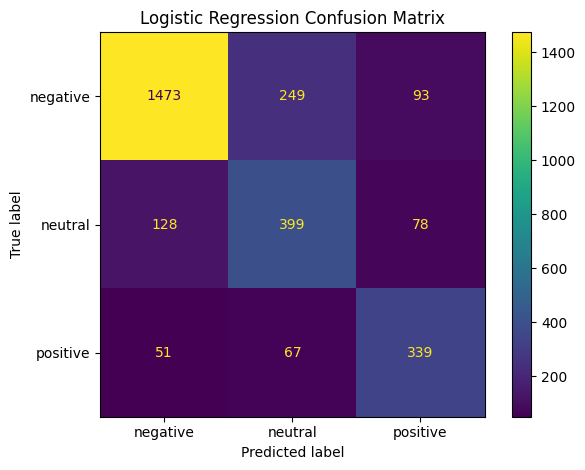

In [26]:
cm_lr = confusion_matrix(
    y_test,
    predictions["Logistic Regression"],
    labels=class_order,
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=class_order,
).plot(values_format="d")

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## Logistic Regression Interpretation

Logistic Regression provides the strongest macro F1 score in this comparison. It identifies the negative class reliably while also retaining substantially better recall for neutral and positive tweets than Naive Bayes. The most common errors occur between neutral and negative tweets, which is expected because informational complaints can contain both factual and dissatisfied language.

The model is a strong deployment candidate because it offers balanced class performance, efficient training, probability estimates, and coefficients that can be inspected for interpretability.

## Multinomial Naive Bayes Evaluation

In [27]:
nb_metrics = calculate_metrics(
    y_test,
    predictions["Multinomial Naive Bayes"],
)

display(
    pd.DataFrame(
        [nb_metrics],
        index=["Multinomial Naive Bayes"],
    )
)

print(
    classification_report(
        y_test,
        predictions["Multinomial Naive Bayes"],
        labels=class_order,
        digits=3,
        zero_division=0,
    )
)

,Accuracy,Precision Macro,Recall Macro,F1 Macro
Multinomial Naive Bayes,0.758081,0.767844,0.597696,0.639685


              precision    recall  f1-score   support

    negative      0.754     0.967     0.847      1815
     neutral      0.722     0.322     0.446       605
    positive      0.827     0.503     0.626       457

    accuracy                          0.758      2877
   macro avg      0.768     0.598     0.640      2877
weighted avg      0.759     0.758     0.728      2877



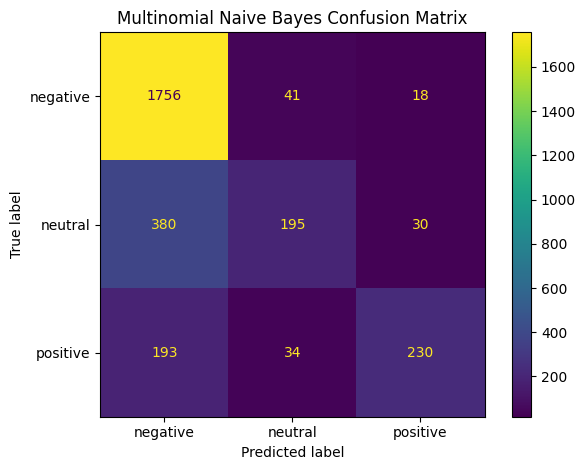

In [28]:
cm_nb = confusion_matrix(
    y_test,
    predictions["Multinomial Naive Bayes"],
    labels=class_order,
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=class_order,
).plot(values_format="d")

plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

## Multinomial Naive Bayes Interpretation

Naive Bayes trains almost instantly and performs well on the dominant negative class. Its weakness is low recall for neutral and positive tweets. The confusion matrix shows that many minority class examples are incorrectly assigned to the negative class. This produces acceptable overall accuracy but a weaker macro F1 score. The result demonstrates why accuracy alone is insufficient for an imbalanced multiclass problem.

## Linear SVC Evaluation

In [29]:
svc_metrics = calculate_metrics(
    y_test,
    predictions["Linear SVC"],
)

display(pd.DataFrame([svc_metrics], index=["Linear SVC"]))

print(
    classification_report(
        y_test,
        predictions["Linear SVC"],
        labels=class_order,
        digits=3,
        zero_division=0,
    )
)

,Accuracy,Precision Macro,Recall Macro,F1 Macro
Linear SVC,0.771985,0.705756,0.713118,0.709326


              precision    recall  f1-score   support

    negative      0.866     0.851     0.859      1815
     neutral      0.574     0.590     0.582       605
    positive      0.677     0.698     0.688       457

    accuracy                          0.772      2877
   macro avg      0.706     0.713     0.709      2877
weighted avg      0.775     0.772     0.773      2877



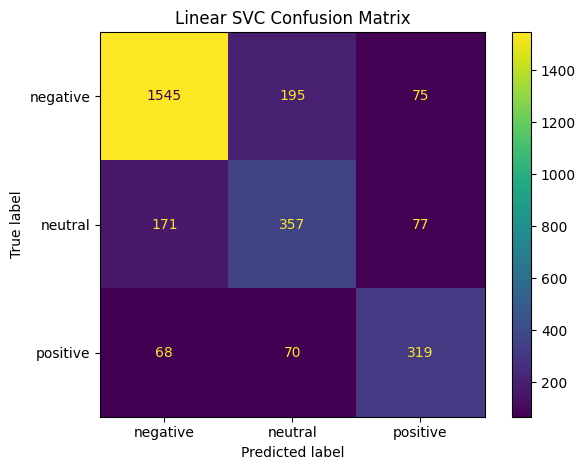

In [30]:
cm_svc = confusion_matrix(
    y_test,
    predictions["Linear SVC"],
    labels=class_order,
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=class_order,
).plot(values_format="d")

plt.title("Linear SVC Confusion Matrix")
plt.tight_layout()
plt.show()

## Linear SVC Interpretation

Linear SVC achieves the highest accuracy in the comparison and the strongest negative class F1 score. Its macro F1 score is slightly lower than Logistic Regression because neutral and positive performance is less balanced. The model remains a strong technical alternative, especially when the primary goal is maximum classification accuracy with low training cost.

## Model Comparison

In [31]:
comparison_rows = []

for model_name, y_pred in predictions.items():
    row = {"Model": model_name}
    row.update(calculate_metrics(y_test, y_pred))
    row["Training Time Seconds"] = training_times[model_name]
    comparison_rows.append(row)

results = (
    pd.DataFrame(comparison_rows)
    .sort_values("F1 Macro", ascending=False)
    .reset_index(drop=True)
)

display(results.round(4))

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Training Time Seconds
0,Logistic Regression,0.7685,0.7048,0.7376,0.7185,3.9394
1,Linear SVC,0.7720,0.7058,0.7131,0.7093,0.7189
2,Multinomial Naive Bayes,0.7581,0.7678,0.5977,0.6397,0.1949


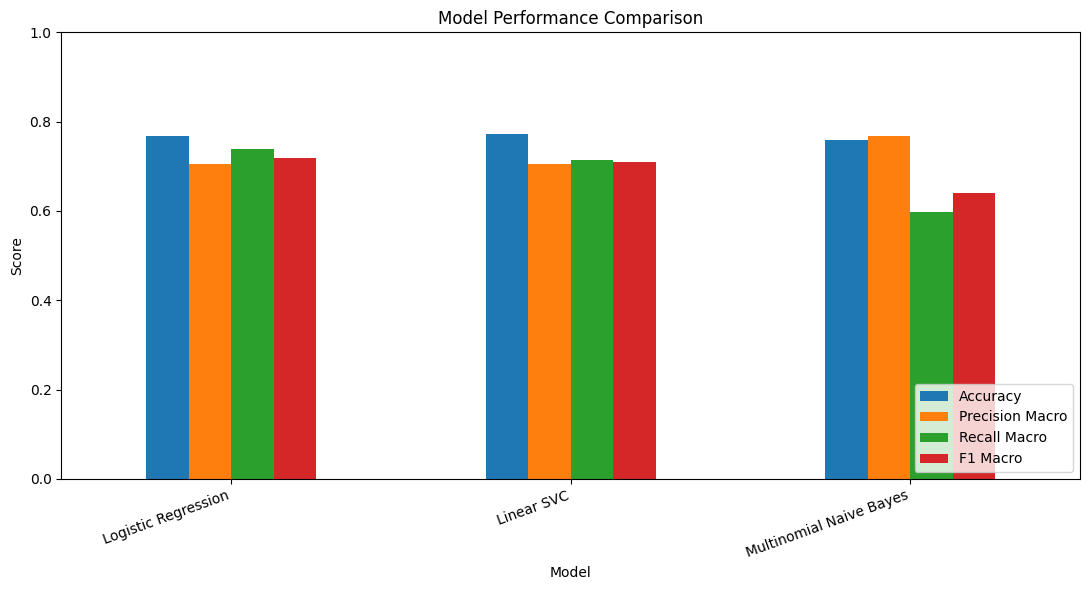

In [32]:
metric_columns = [
    "Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
]

results.set_index("Model")[metric_columns].plot(
    kind="bar",
    figsize=(11, 6),
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Model Comparison Analysis

**Best balanced model:** Logistic Regression

**Highest accuracy:** Linear SVC

**Fastest training:** Multinomial Naive Bayes

Macro F1 is prioritised because all three classes matter to the business. A system that detects negative tweets but overlooks positive and neutral tweets would distort customer sentiment reporting. Logistic Regression is recommended because it provides the best balance across classes and can return class probabilities that support confidence based routing.

Linear SVC is a close alternative when slightly higher accuracy is more important than probability output. Naive Bayes is valuable as a rapid baseline, but its minority class recall is too weak for the recommended operational use.

## Error Analysis

In [33]:
# Review a sample of Logistic Regression errors

error_analysis = pd.DataFrame(
    {
        "Original Text": df.loc[X_test.index, "text"].values,
        "Cleaned Text": X_test.values,
        "Actual Sentiment": y_test.values,
        "Predicted Sentiment": predictions["Logistic Regression"],
    }
)

error_analysis = error_analysis[
    error_analysis["Actual Sentiment"]
    != error_analysis["Predicted Sentiment"]
]

print(f"Total Logistic Regression errors: {len(error_analysis)}")

display(
    error_analysis.sample(
        n=min(12, len(error_analysis)),
        random_state=RANDOM_STATE,
    )
)

Total Logistic Regression errors: 666


,Original Text,Cleaned Text,Actual Sentiment,Predicted Sentiment
2607,@united need help. Never got tickets. Conf #ggqzqd,need help never got tickets conf ggqzqd,neutral,negative
694,@SouthwestAir you cx'ed almost the entire east coast flights All other planes are taking off any traveling fine I need to get to Nev ASAP,cx ed entire east coast flights planes taking traveling fine need nev asap,negative,neutral
2707,"@SouthwestAir Yes, but I like need my luggage before tomorrow morning",yes like need luggage tomorrow morning,negative,neutral
997,@VirginAmerica Nice to see you expanding in Texas but don't forget about us here in #SanDiego. I would love to see more flights out of here!,nice expanding texas not forget sandiego love flights,neutral,positive
2139,"@united although, I am stranded in Chicago O'Hare for another 8 hours. Any chance your cracker-jack service team could provide a meal?",stranded chicago hare hours chance cracker jack service team provide meal,negative,neutral
1504,@AmericanAir I'm trying to reach the advantage department to add my number to a recent flight,trying reach advantage department add number recent flight,negative,neutral
1633,@SouthwestAir discount for three delays?,discount delays,negative,neutral
1843,@united love the new 1st class breakfast!,love new st class breakfast,positive,neutral
2322,@VirginAmerica is helping me step up my @Tinder game! #TinderTips #tinderchamp http://t.co/jBmVVha63A,helping step game tindertips tinderchamp,neutral,negative
390,@AmericanAir wish you had a better mobile app. You should look at the app from @united as it is much more seemless to check in,wish better mobile app look app seemless check,negative,neutral


## Error Analysis Insights

Common errors involve short tweets, sarcasm, mixed sentiment, ambiguous questions, and messages that contain both appreciation and a complaint. A tweet may thank an airline employee while criticising a delay, making a single label difficult. Removing account mentions also eliminates some airline context, although this was an intentional decision to reduce reliance on company identity.

Potential improvements include adding character ngrams, using emoji features, retaining selected punctuation, tuning decision thresholds, and testing transformer based language models that can capture context and sarcasm more effectively.

# Part 6: Conclusion and Business Insights

## Executive Summary

This project analysed public customer tweets about six major U.S. airlines and trained three sentiment classification models. The data was strongly weighted toward negative sentiment, so macro F1 score was used as the primary comparison metric. Logistic Regression produced the best balanced performance across negative, neutral, and positive classes, while Linear SVC achieved the highest overall accuracy. The recommended model can support customer service triage and trend monitoring, but sensitive or high impact complaints should remain subject to human review.

## Key Findings

1. Negative sentiment is the dominant class in the dataset.
2. Negative tweets are generally longer than neutral and positive tweets.
3. Duplicate text removal and train only TF IDF fitting reduced leakage risk.
4. Naive Bayes was extremely fast but overpredicted negative sentiment.
5. Linear SVC achieved the highest accuracy.
6. Logistic Regression achieved the strongest macro F1 score and the most balanced class recall.
7. Neutral sentiment was the most difficult class because many neutral messages contain complaint related or ambiguous language.

## Business Recommendations

1. Use Logistic Regression as the initial operational model for sentiment triage.
2. Route high confidence negative predictions to a customer recovery queue.
3. Use class probabilities to send uncertain predictions for human review.
4. Monitor sentiment by issue type, airline, and time period rather than relying only on a single aggregate percentage.
5. Keep safety, accessibility, discrimination, medical, and refund related complaints under human oversight.
6. Reassess performance regularly because language, customer expectations, and airline operations change over time.
7. Audit error rates across relevant customer groups when demographic or location data is introduced.

## Limitations

1. The dataset represents public tweets from a limited historical period and may not reflect current airline customers.
2. Social media users are not a random sample of all passengers.
3. Sentiment labels can be subjective, especially for sarcasm and mixed emotion.
4. The model does not distinguish complaint categories or urgency.
5. User mentions, URLs, punctuation, and most metadata were excluded.
6. Conventional TF IDF models do not fully understand context, humour, irony, or long distance word relationships.
7. Performance on this test set does not guarantee equal performance in a live production environment.

## Future Improvements

1. Compare word ngrams with character ngrams.
2. Tune hyperparameters using stratified cross validation.
3. Test calibrated Linear SVC or additional probabilistic classifiers.
4. Evaluate modern transformer models such as DistilBERT.
5. Add complaint category classification for delays, baggage, refunds, customer service, and cancellations.
6. Create confidence thresholds and a human review workflow.
7. Monitor data drift, class distribution changes, and class specific recall after deployment.
8. Build a reproducible pipeline that combines preprocessing, vectorisation, and classification in one object.

## Lessons Learned

This project strengthened my understanding of the complete machine learning workflow for text data. I learned that data quality review and class balance analysis are essential before model training. I also learned why TF IDF must be fit only on training data and why macro F1 can be more informative than accuracy for imbalanced classification.

The comparison showed that the fastest model is not always the most useful model. Naive Bayes trained very quickly, but Logistic Regression produced a better balance among the three classes. The error analysis also demonstrated that model metrics should be combined with inspection of real examples because sarcasm, mixed sentiment, and short messages remain difficult for conventional algorithms.

# References

1. CrowdFlower. *Twitter U.S. Airline Sentiment*. Kaggle dataset. https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

2. Hugging Face. *Twitter U.S. Airline Sentiment Dataset Mirror*. https://huggingface.co/datasets/osanseviero/twitter-airline-sentiment

3. Scikit learn. *TfidfVectorizer Documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

4. Scikit learn. *LogisticRegression Documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

5. Scikit learn. *MultinomialNB Documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

6. Scikit learn. *LinearSVC Documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

# Final Submission Check

**Individual student:** Idris Junaid  

The notebook includes all six required project parts, three classification models, multiple evaluation metrics, confusion matrices, business recommendations, limitations, future improvements, and a personal learning reflection.

**Required filename:** `FP_AirlineSentiment_IdrisJunaid.ipynb`